# OOK Modulation/Demodulation Demo

このノートブックでは、`Delta_M.ipynb` で使用されたオーディオサンプルを用いて、OOK (On-Off Keying) 変調および復号のプロセスをデモンストレーションします。

**手順:**
1. オーディオ信号の読み込み
2. デルタ変調によるデジタル信号(ビット列)への変換
3. OOK変調 (搬送波との乗算)
4. OOK復号 (包絡線検波)
5. デルタ復調による音声再構成
6. 結果の可視化と音声再生

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd
from scipy.signal import butter, lfilter, filtfilt

# プロットスタイルの設定
import seaborn as sns
sns.set()

## 1. オーディオ信号の読み込み
`Delta_M.ipynb` と同様のサンプル音声を読み込みます。

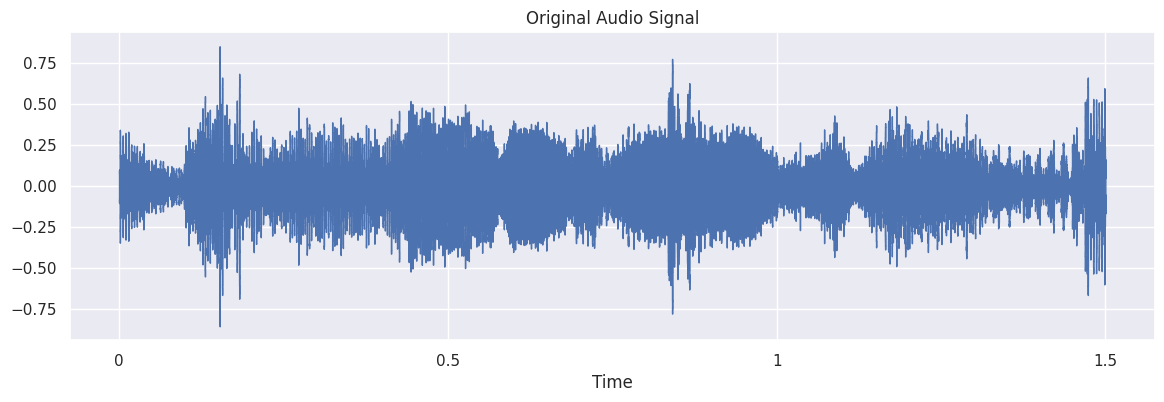

Original Audio:


In [ ]:
# 音声のロード
y, sr = librosa.load(librosa.ex('fishin'), offset=15, duration=1.5)

# 時間軸の生成
t = np.linspace(0, len(y)/sr, len(y))

# オリジナル音声の確認
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Original Audio Signal')
plt.show()

print("Original Audio:")
ipd.Audio(y, rate=sr)

## 2. デルタ変調 (Encoding)
オーディオ信号をデジタルビット列（0と1）に変換するために、デルタ変調を行います。

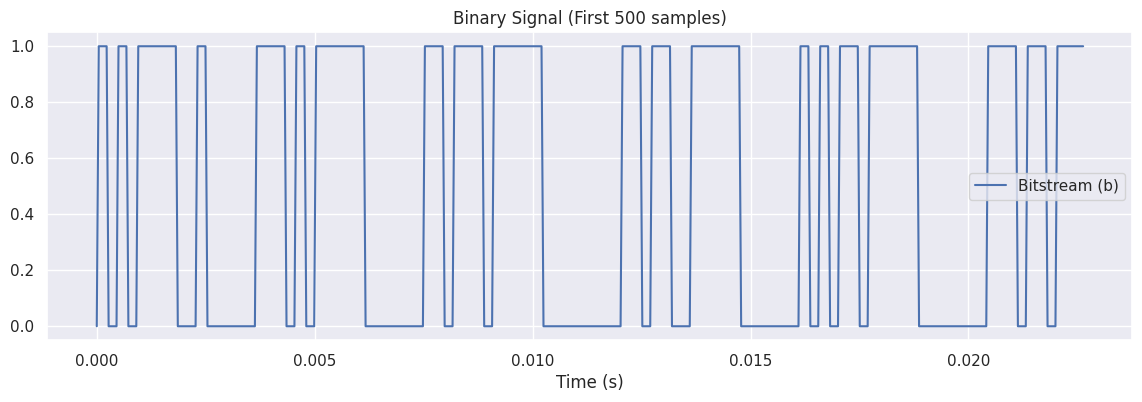

In [ ]:
delta_y = 0.05
skip_t = 5

# yが元信号波形
# bがデルタ変調波形 (ビット列に相当)
# zはデルタ変調から再生された波形 (参照用)
z_ref = np.zeros(len(y))
b = np.zeros(len(y))
z_ref[0] = y[0]
b[0] = 0

for i in range(1, len(y)-1, skip_t):
    diff = y[i] - z_ref[i-1]
    if diff < 0:
        z_ref[i] = z_ref[i-1] - delta_y
        b[i] = 0
    else:
        z_ref[i] = z_ref[i-1] + delta_y
        b[i] = 1
    
    # サンプリング間隔の間は値を保持（矩形波化）
    for j in range(i+1, min(i+skip_t, len(y)-1)):
        z_ref[j] = z_ref[i]
        b[j] = b[i]

plt.figure(figsize=(14, 4))
plt.plot(t[:500], b[:500], label='Bitstream (b)')
plt.title('Binary Signal (First 500 samples)')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

## 3. OOK変調 (On-Off Keying)
ビット列 `b` を用いて搬送波をオン・オフします。
$$ s(t) = b(t) \times A \cos(2\pi f_c t) $$
ここで $f_c$ は搬送波周波数です。

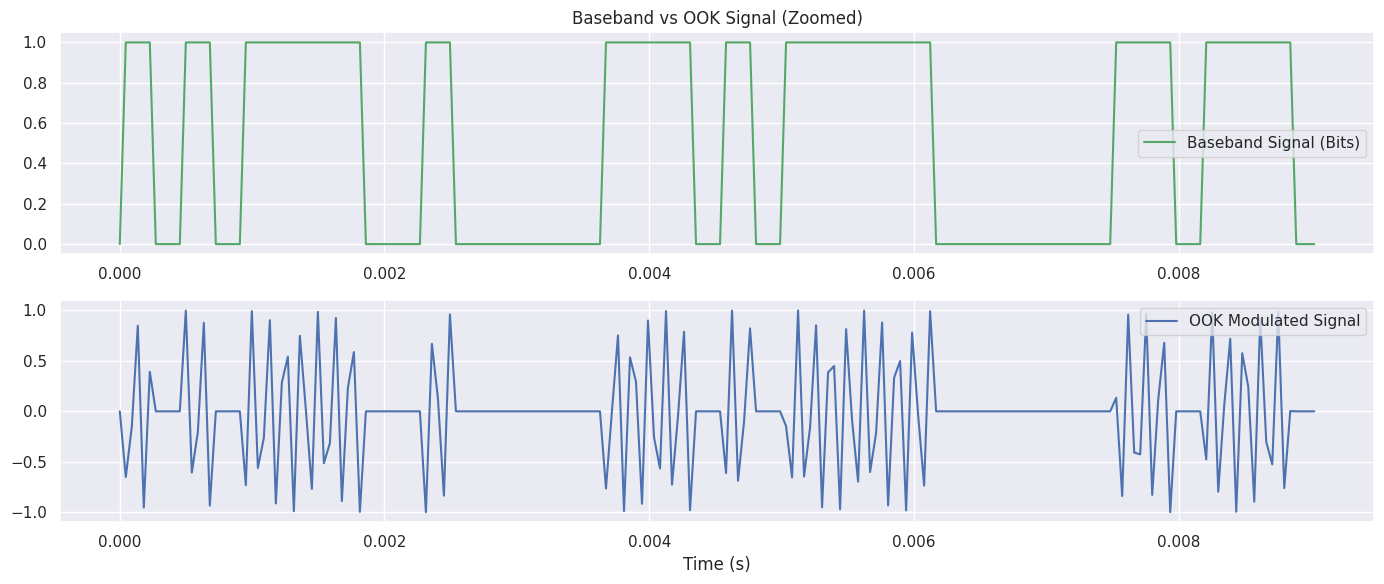

In [ ]:
# 搬送波周波数 (サンプリング周波数の半分以下である必要があります)
# ビットレートは sr / skip_t = 22050 / 5 = 4410 bps
# 搬送波はこれより十分高い周波数にします
fc = 8000  # 8 kHz

# 搬送波の生成
carrier = np.cos(2 * np.pi * fc * t)

# OOK変調
ook_signal = b * carrier

# 変調波形の確認 (一部拡大)
plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(t[:200], b[:200], 'g', label='Baseband Signal (Bits)')
plt.title('Baseband vs OOK Signal (Zoomed)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t[:200], ook_signal[:200], label='OOK Modulated Signal')
plt.xlabel('Time (s)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. OOK復号 (OOK Demodulation)
包絡線検波を用いて元のビット列を復元します。
1. 絶対値をとる（整流）
2. ローパスフィルタを通す（平滑化）
3. 閾値判定

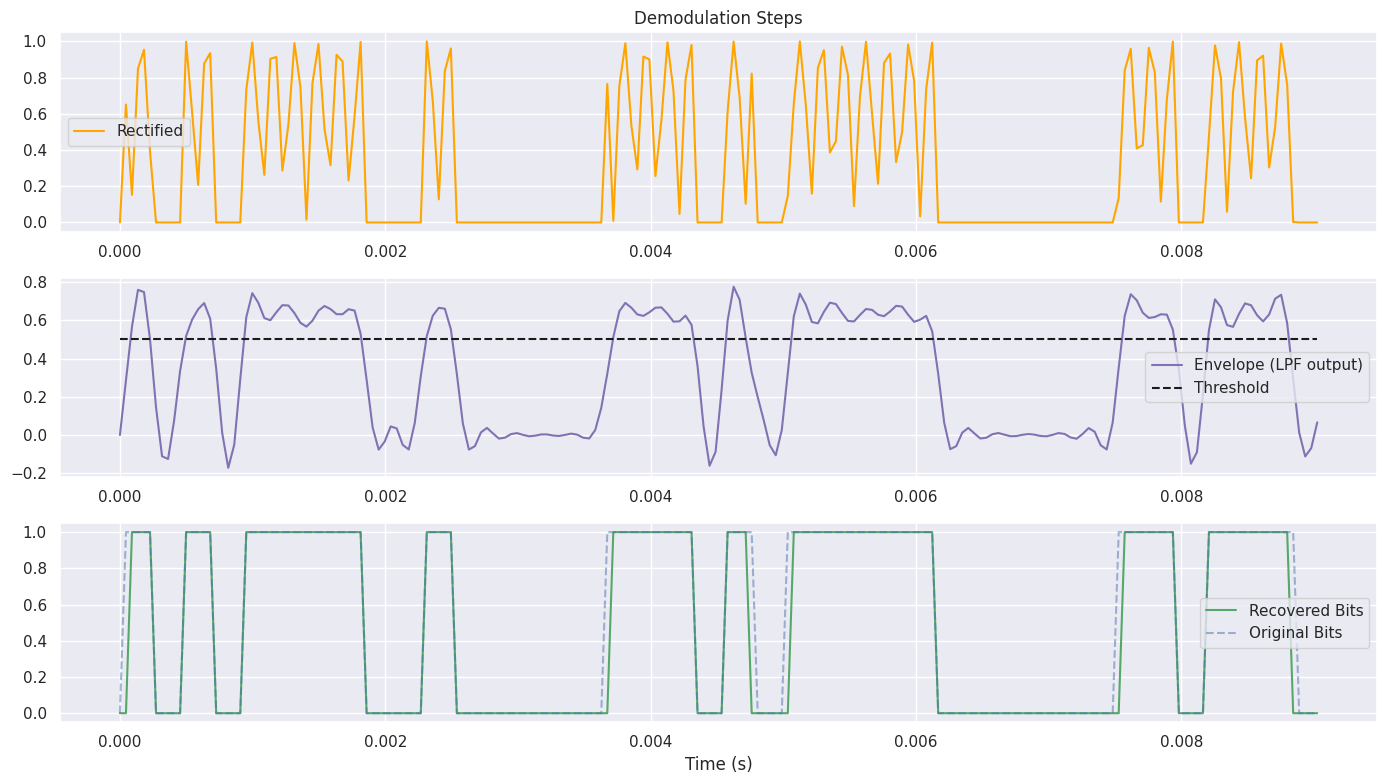

In [ ]:
# 1. 整流 (Rectification)
rectified = np.abs(ook_signal)

# 2. ローパスフィルタ (Low-pass filtering)
def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    # filtfiltを使用して位相遅れ（遅延）を防ぐ
    y = filtfilt(b, a, data)
    return y

# カットオフ周波数はビットレートより少し高く設定
cutoff = 4500 # 4.5 kHz
envelope = butter_lowpass_filter(rectified, cutoff, sr, order=6)

# 3. 閾値判定 (Thresholding)
threshold = 0.5
b_recovered = (envelope > threshold).astype(float)

# 復号結果の確認
plt.figure(figsize=(14, 8))
plt.subplot(3, 1, 1)
plt.plot(t[:200], rectified[:200], color='orange', label='Rectified')
plt.title('Demodulation Steps')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t[:200], envelope[:200], color='m', label='Envelope (LPF output)')
plt.plot(t[:200], [threshold]*200, 'k--', label='Threshold')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t[:200], b_recovered[:200], color='g', label='Recovered Bits')
plt.plot(t[:200], b[:200], 'b--', alpha=0.5, label='Original Bits')
plt.xlabel('Time (s)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. デルタ復調による音声再構成
復元されたビット列 `b_recovered` から音声を再構成します。

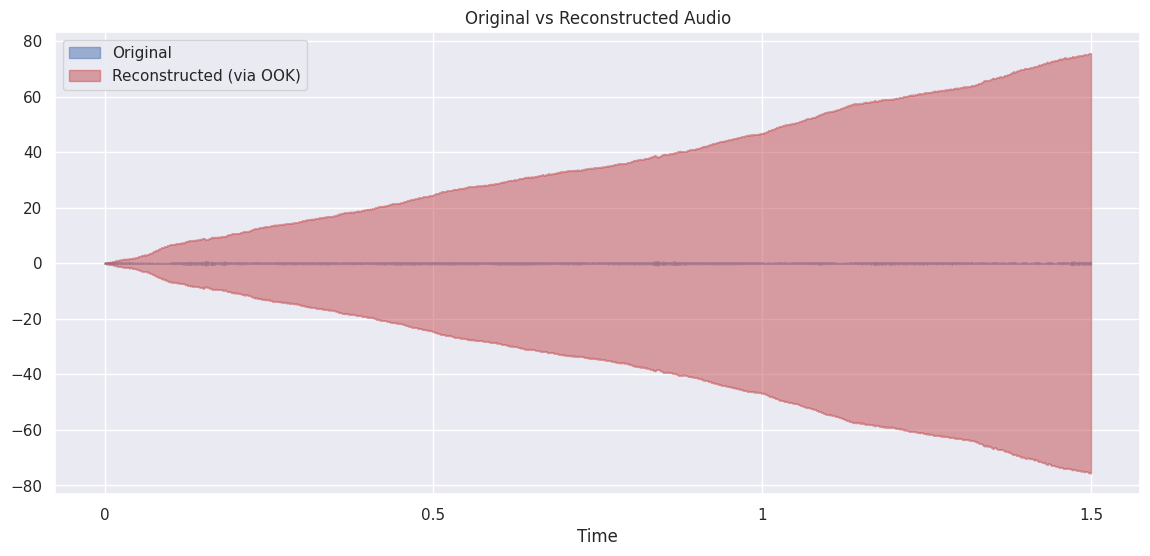

Reconstructed Audio (via OOK):


In [ ]:
z_rec = np.zeros(len(b_recovered))
z_rec[0] = y[0]

# デルタ復調ロジック
for i in range(1, len(b_recovered), skip_t):
    # ビットが1なら増加、0なら減少
    # ノイズ除去のため、多数決やサンプリング点の代表値を取るのが理想ですが、
    # ここでは単純にサンプリング点の値を使用します
    val = b_recovered[i]
    
    if val == 0:
        z_rec[i] = z_rec[i-1] - delta_y
    else:
        z_rec[i] = z_rec[i-1] + delta_y
        
    for j in range(i+1, min(i+skip_t, len(b_recovered))):
        z_rec[j] = z_rec[i]

# 波形の比較
plt.figure(figsize=(14, 6))
librosa.display.waveshow(y, sr=sr, alpha=0.5, label='Original')
librosa.display.waveshow(z_rec, sr=sr, color='r', alpha=0.5, label='Reconstructed (via OOK)')
plt.title('Original vs Reconstructed Audio')
plt.legend()
plt.show()

print("Reconstructed Audio (via OOK):")
ipd.Audio(z_rec, rate=sr)